In [1]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
with open(f'./results/raw_times.pkl', 'rb') as f:
            raw_times = pickle.load(f)
with open(f'./results/norm_times.pkl', 'rb') as f:
            norm_times = pickle.load(f)

## Summary

In [11]:
raw_df = pd.DataFrame.from_dict(raw_times)
raw_df.describe()

,shortest_paths_obj,shortest_distances_obj,Average Degree for Nearest Neighbors (Undirected),Clustering Coefficient,Rich Club Coefficient,Average Local Efficiency,Average Shortest Path Length,Betweenness Centrality,Center,Diameter,...,Max Out-Degree,Number of Arcs,Out-Degree,Regulators,Self Regulations,Gene % in the Giant Component,Undirected Density,get_props,edges,nodes
count,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
mean,0.053635,10.909572,0.022381,6.807581,0.106548,145.401232,0.050322,2.543611,0.318233,0.017142,...,0.001749,0.002000,0.002001,0.001250,0.007877,0.008252,0.002250,573.343399,26106.250000,5935.000000
std,0.040755,10.825931,0.017349,11.899194,0.136271,261.987913,0.037881,2.777493,0.169665,0.012335,...,0.000957,0.001414,0.000819,0.000957,0.003426,0.004925,0.000957,1016.111859,34176.909421,3163.516503
min,0.010003,0.630364,0.004000,0.032000,0.011004,0.636617,0.004000,0.123527,0.078510,0.001003,...,0.000999,0.000000,0.000999,0.000000,0.003000,0.002000,0.001000,2.793889,2876.000000,1713.000000
25%,0.037781,6.154511,0.013749,0.953279,0.037251,14.964537,0.033680,1.301660,0.285562,0.013749,...,0.001000,0.001500,0.001749,0.000750,0.006753,0.006503,0.001750,68.552741,9444.500000,5021.250000
50%,0.048002,8.414704,0.019999,1.281934,0.053317,21.432954,0.050825,1.751989,0.357906,0.018260,...,0.001500,0.002500,0.002000,0.001500,0.009002,0.008502,0.002499,97.278162,12310.000000,6328.000000
75%,0.063856,13.169766,0.028631,7.136235,0.122614,151.869650,0.067467,2.993940,0.390577,0.021653,...,0.002249,0.003000,0.002251,0.002000,0.010126,0.010250,0.002999,602.068821,28971.750000,7241.750000
max,0.108534,26.178517,0.045527,24.634455,0.308554,538.102403,0.095639,6.546939,0.478612,0.031047,...,0.002999,0.003000,0.003005,0.002000,0.010503,0.014003,0.003000,2096.023382,76929.000000,9371.000000


## Overall times

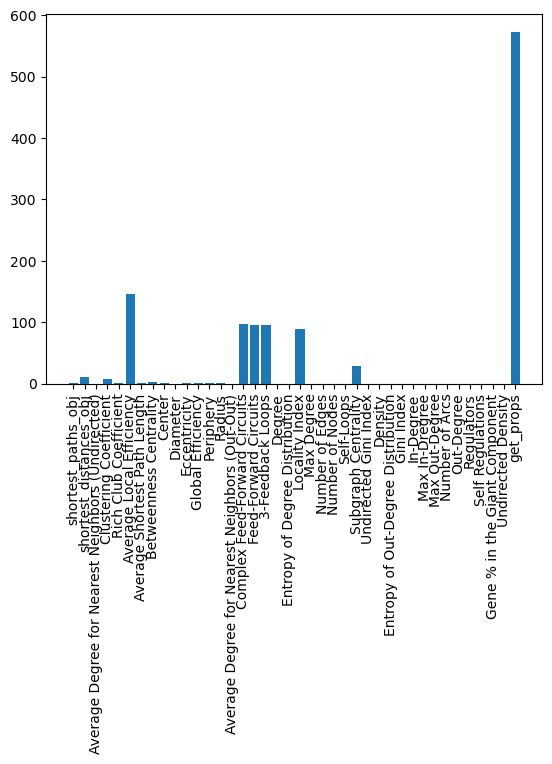

In [5]:
raw_means = {}

for prop, times in raw_times.items():
    if prop != 'edges' and prop != 'nodes':
        raw_means[prop] = np.asarray(times).mean()

names = list(raw_means.keys())
values = list(raw_means.values())

plt.bar(range(len(raw_means)), values, tick_label=names, align='center')
plt.xticks(rotation = 90)
plt.show()

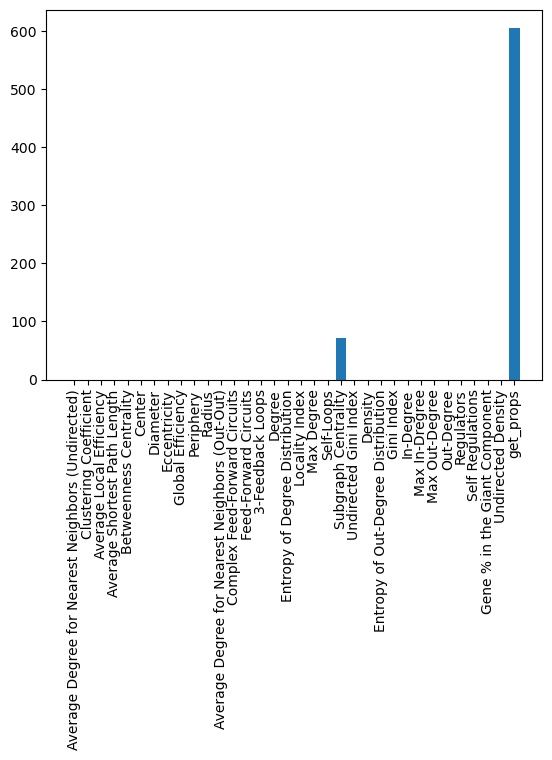

In [6]:
norm_means = {}
for prop, times in norm_times.items():
    if prop != 'edges' and prop != 'nodes':
        norm_means[prop] = np.asarray(times).mean()

names = list(norm_means.keys())
values = list(norm_means.values())

plt.bar(range(len(norm_means)), values, tick_label=names, align='center')
plt.xticks(rotation = 90)
plt.show()

## Relationship between number of edges and computing times

In [7]:
final_df = pd.DataFrame()
for i,(prop, times) in enumerate(raw_times.items()):
    if prop != 'edges' and prop != 'nodes':
        df = pd.DataFrame({'Property': prop, 'Edges': raw_df['edges'], 'Time (s)': times})
        final_df = pd.concat([final_df, df])

final_df

,Property,Edges,Time (s)
0,shortest_paths_obj,11634,0.047040
1,shortest_paths_obj,12986,0.048963
2,shortest_paths_obj,2876,0.010003
3,shortest_paths_obj,76929,0.108534
0,shortest_distances_obj,11634,7.995893
...,...,...,...
3,Undirected Density,76929,0.002998
0,get_props,11634,90.472358
1,get_props,12986,104.083967
2,get_props,2876,2.793889


c:\Users\PepeS\miniconda3\envs\netective\lib\site-packages\seaborn\regression.py:582: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


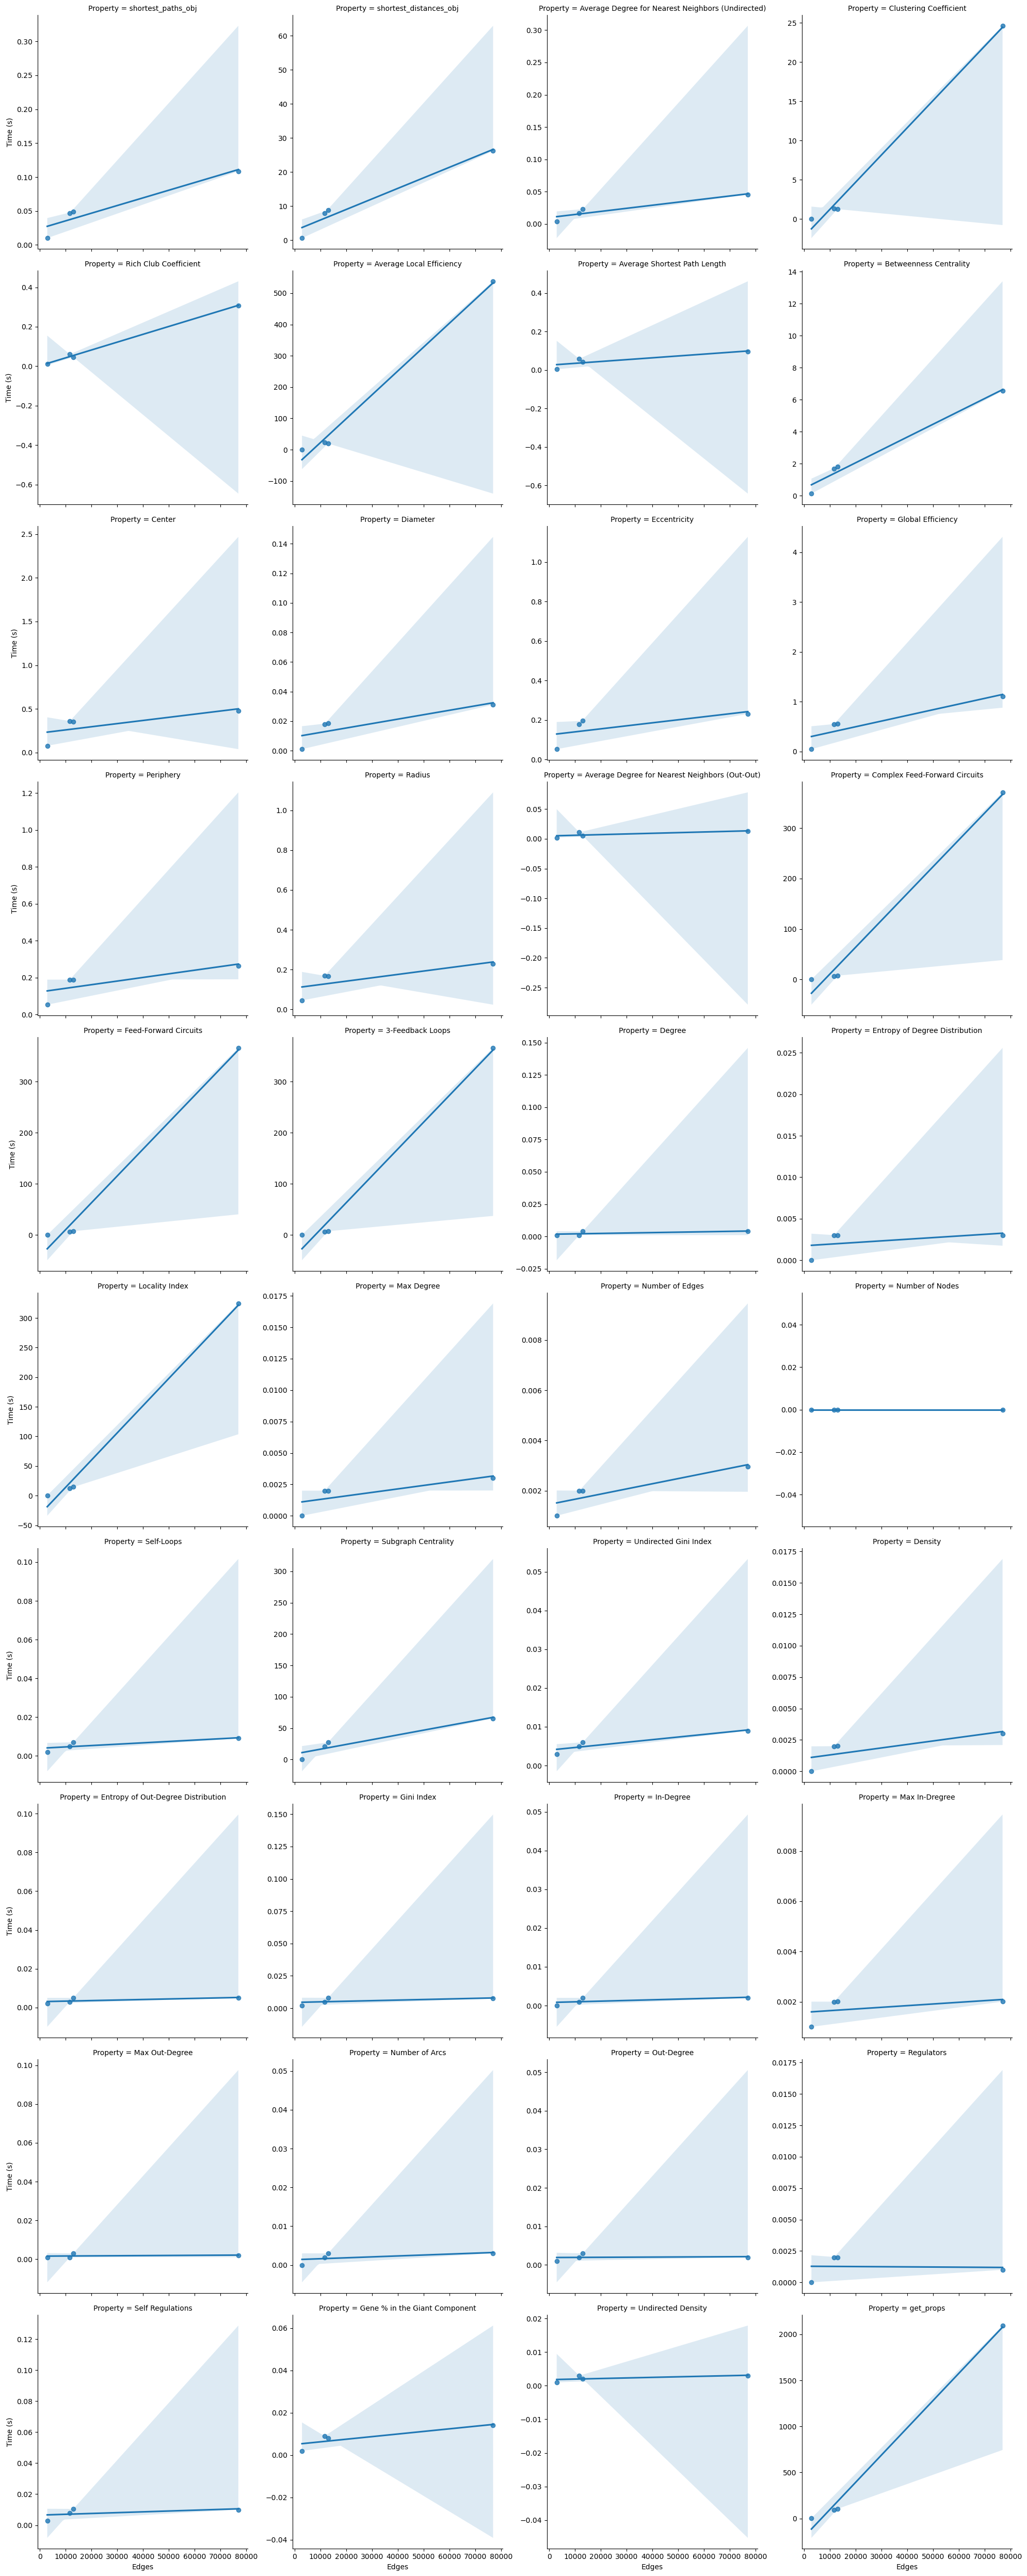

In [8]:
sns.lmplot(x='Edges', y='Time (s)', data=final_df, col='Property', height= 5, aspect= 1, sharey=False, col_wrap=4)

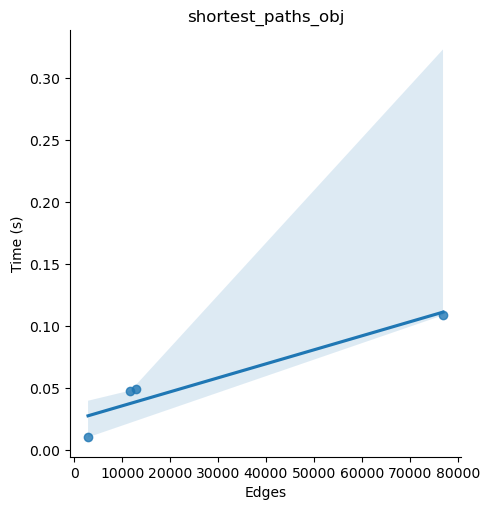

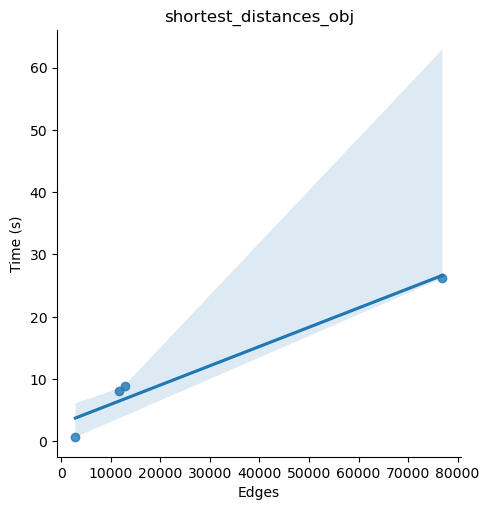

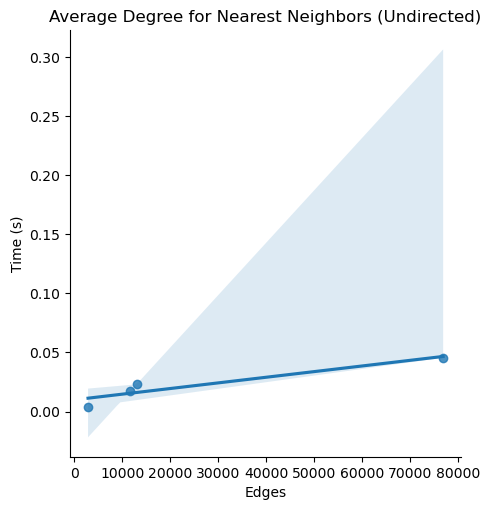

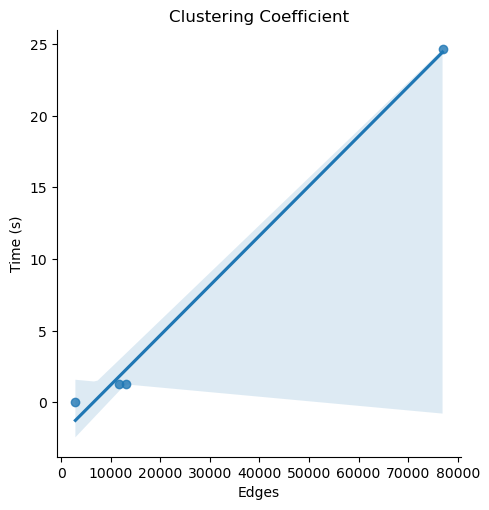

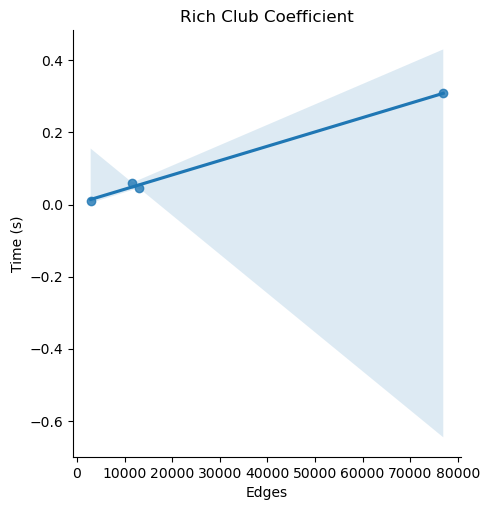

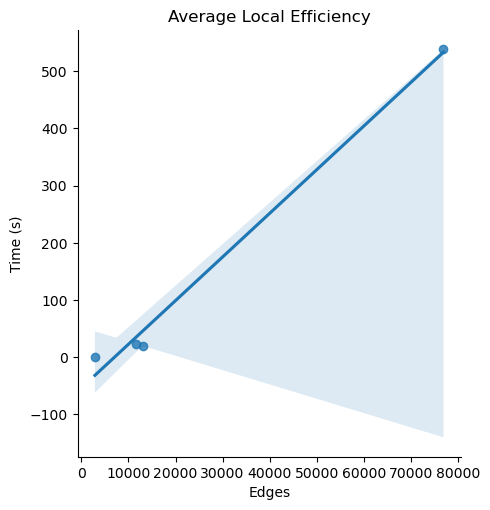

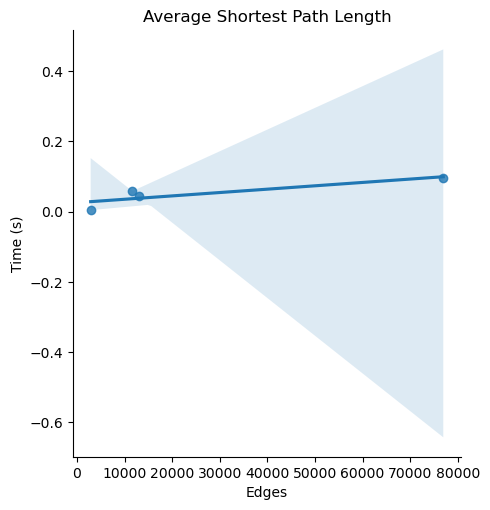

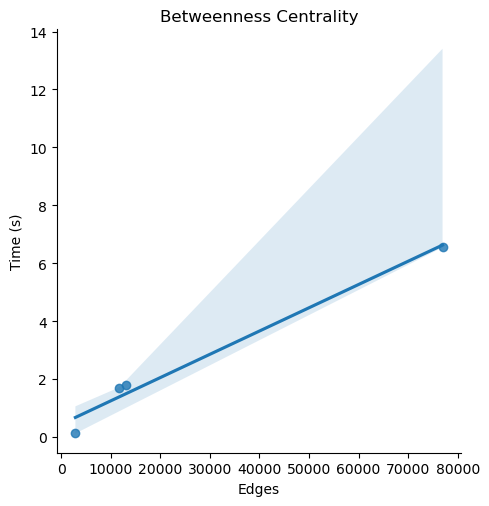

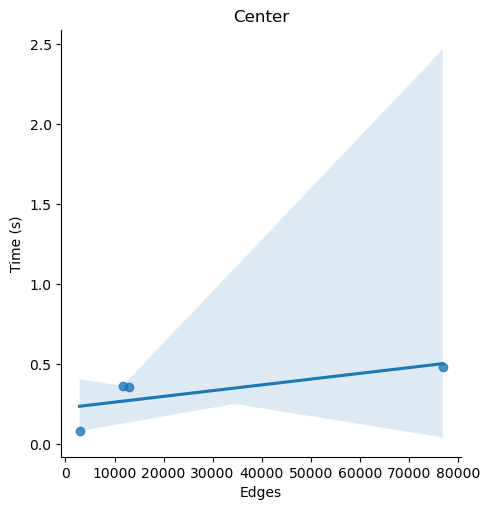

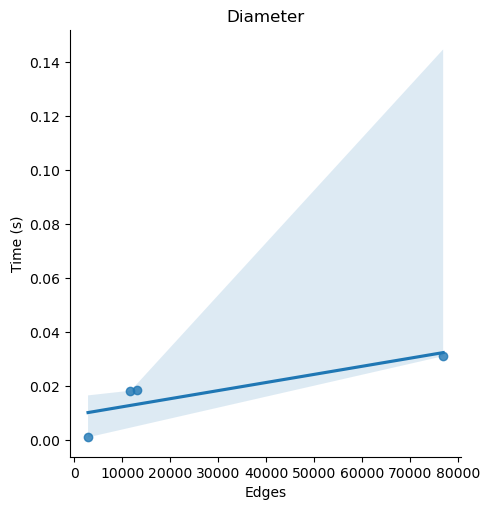

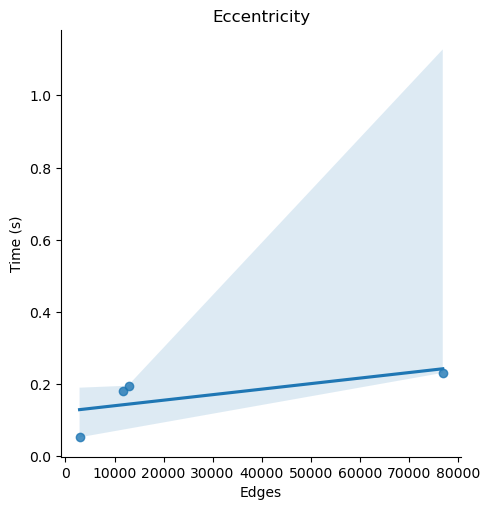

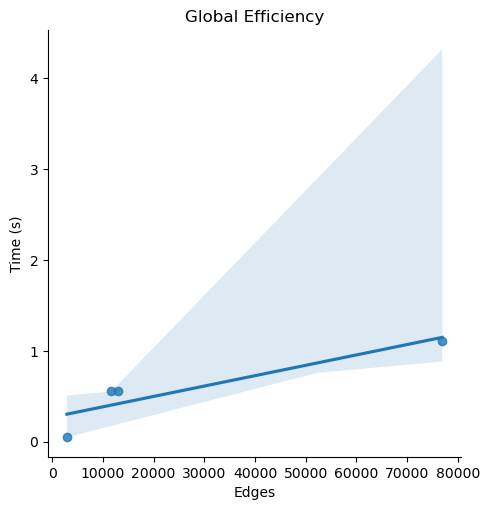

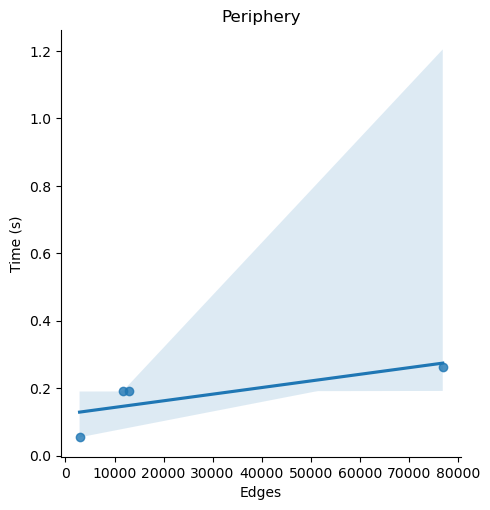

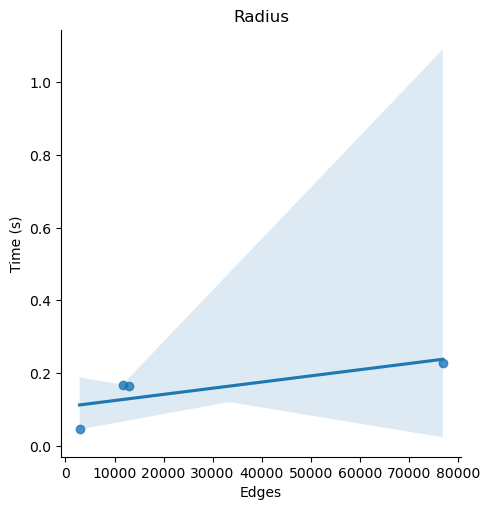

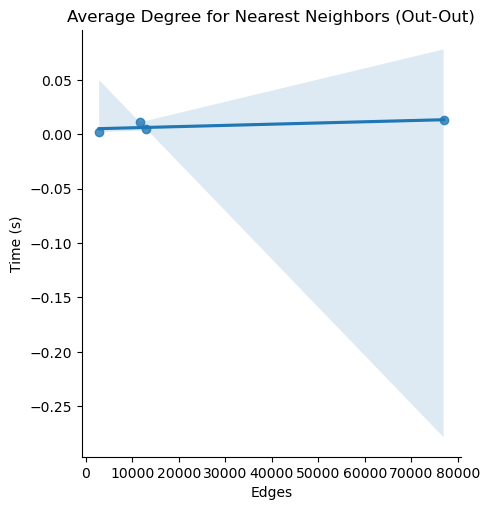

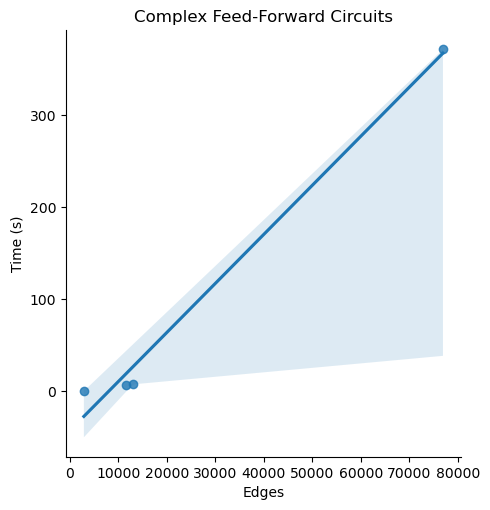

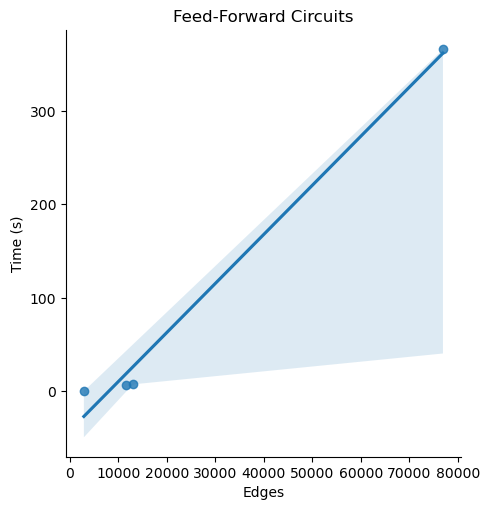

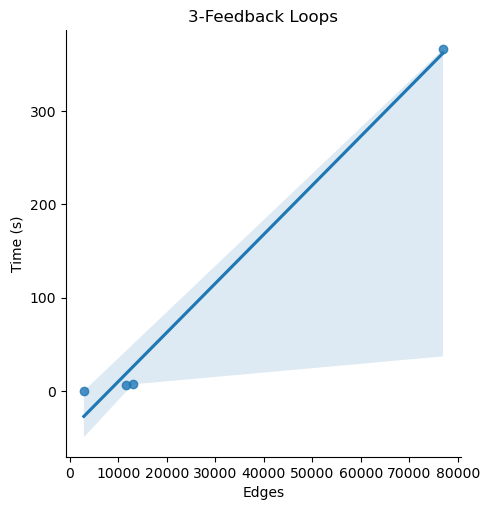

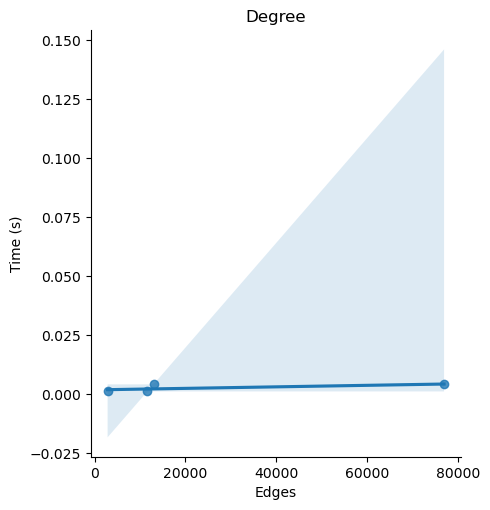

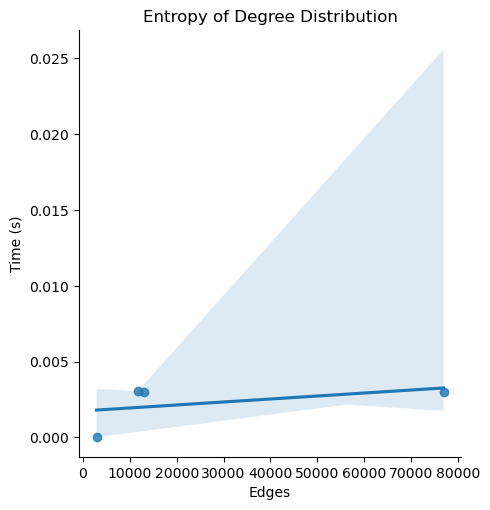

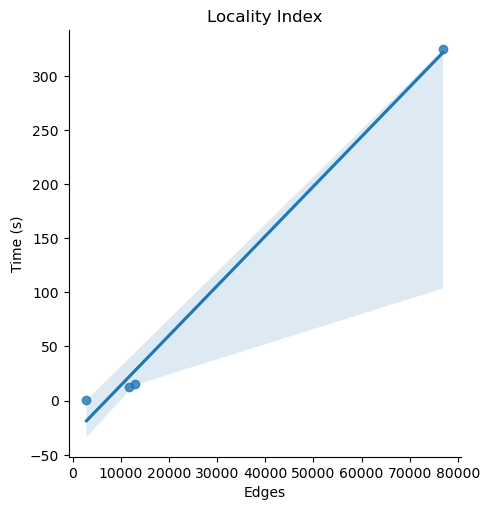

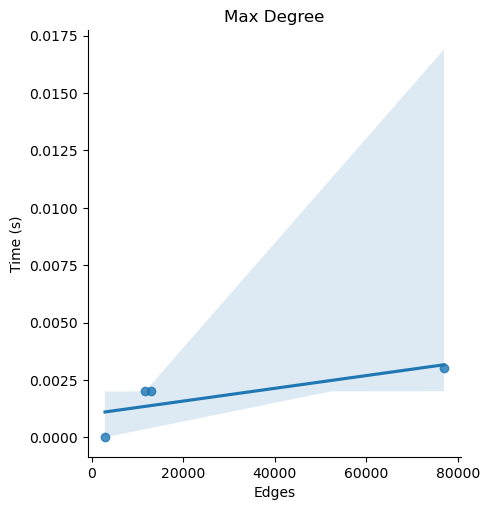

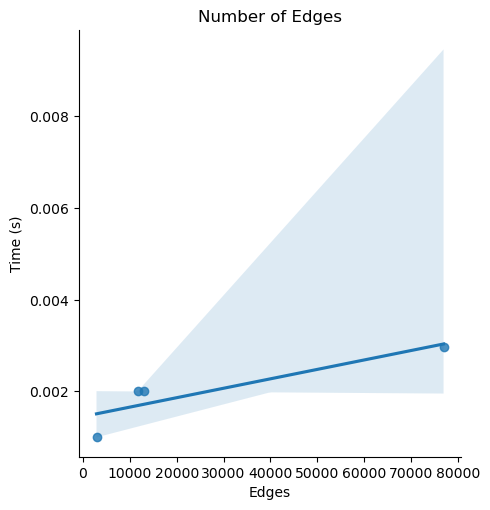

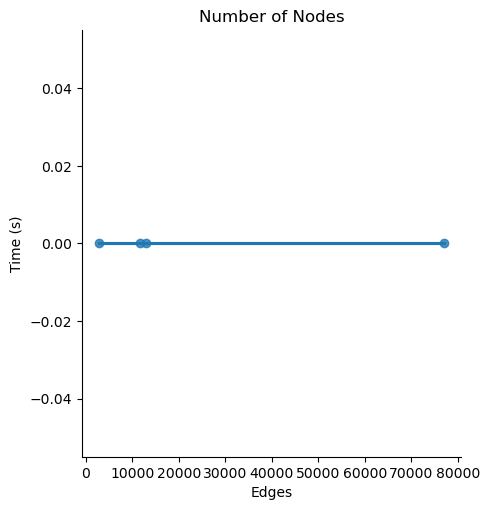

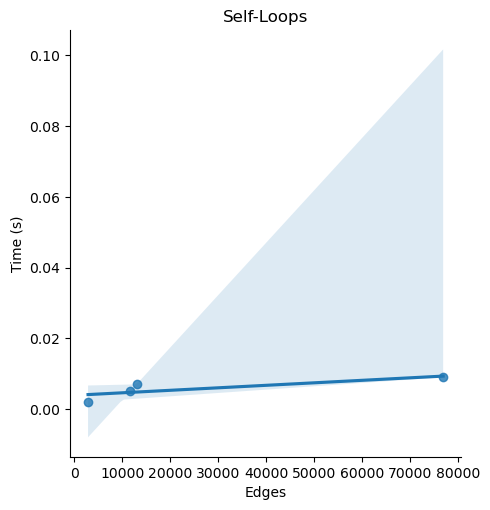

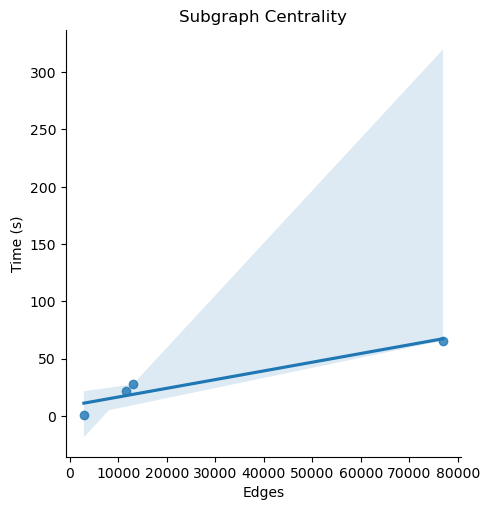

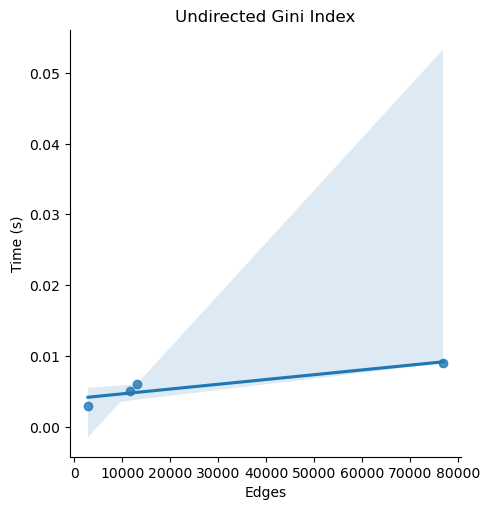

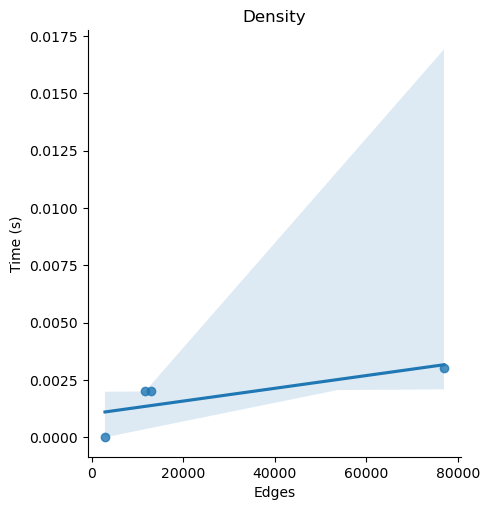

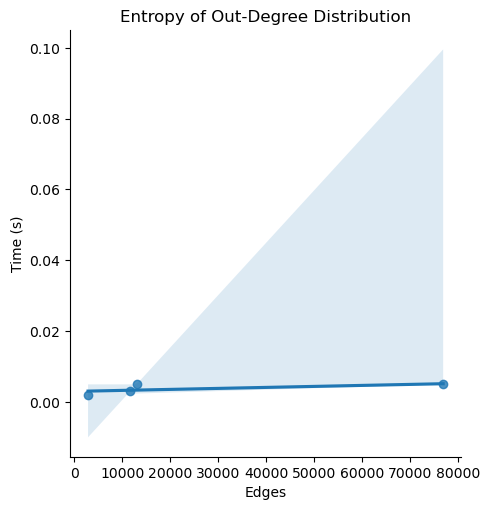

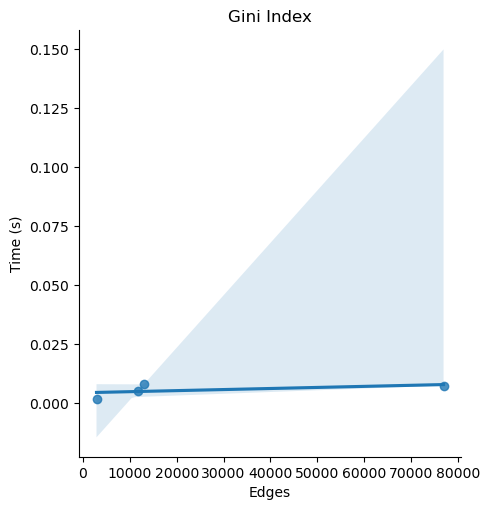

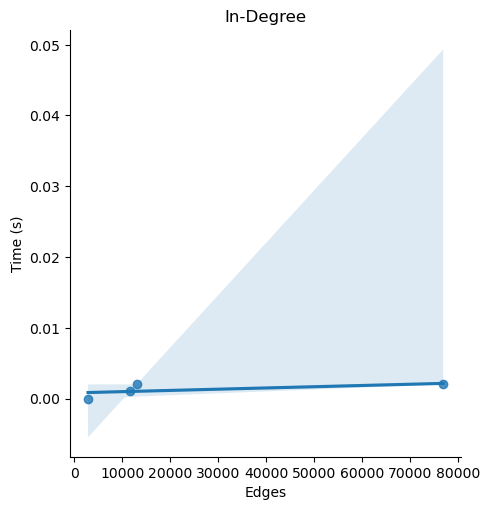

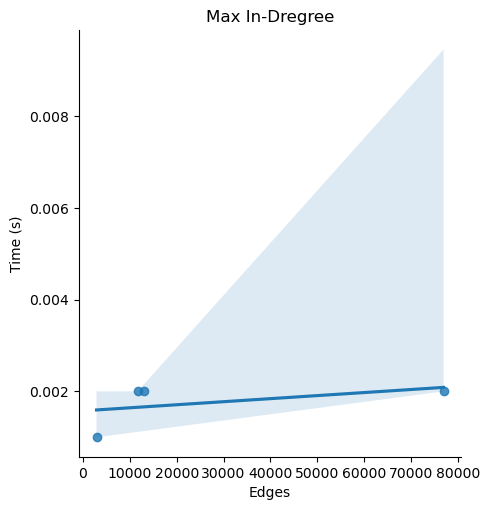

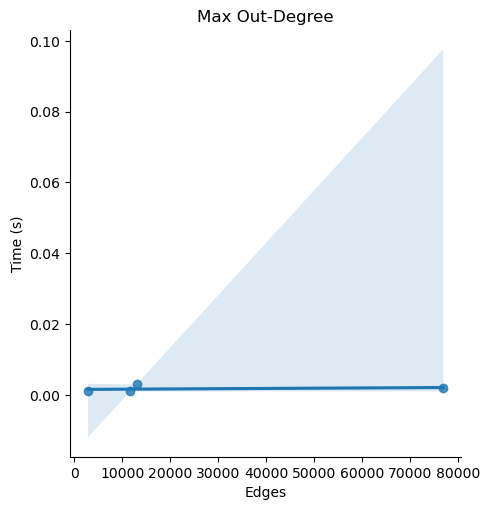

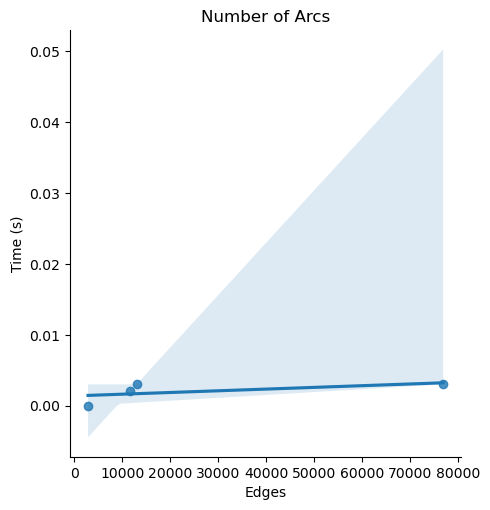

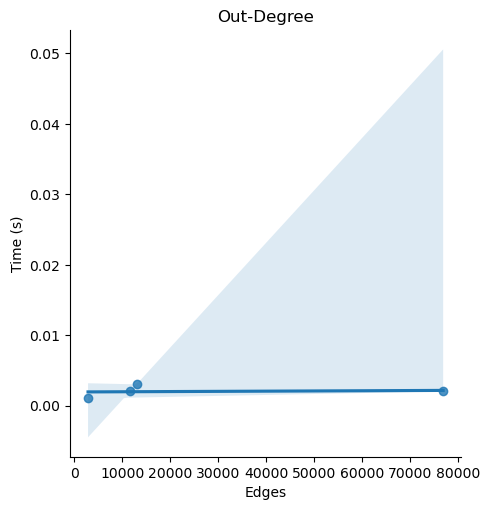

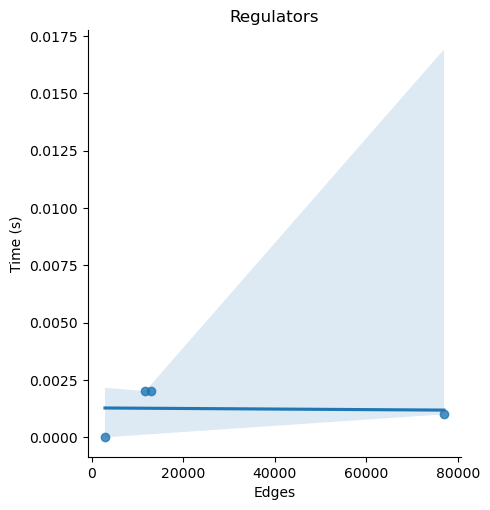

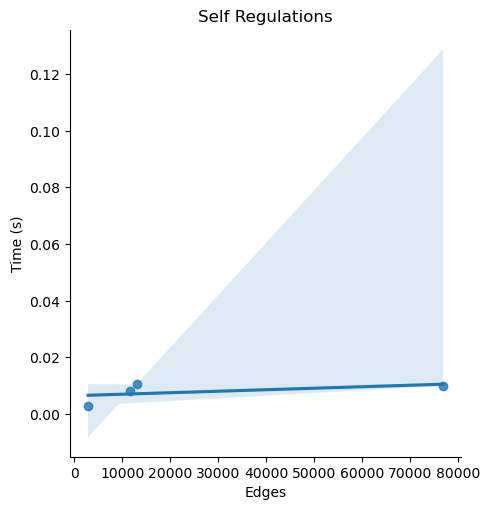

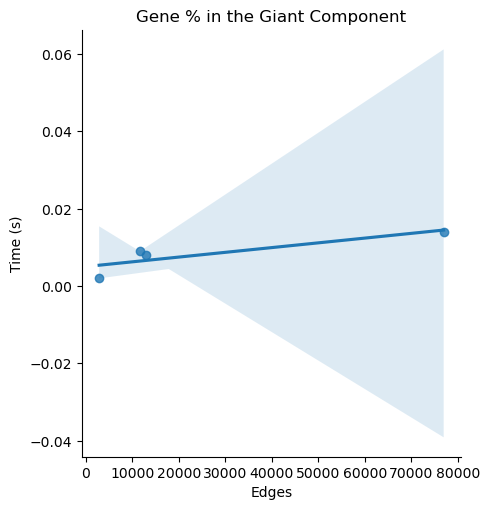

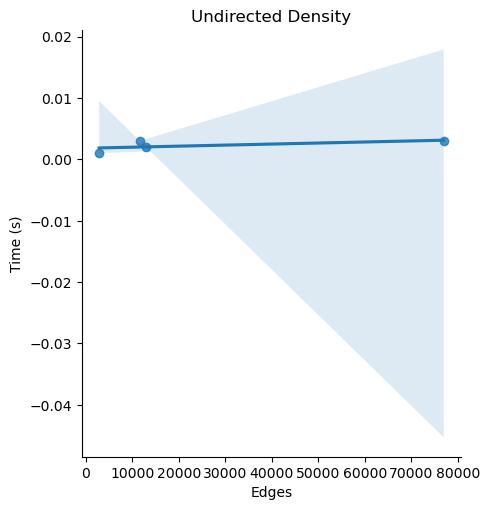

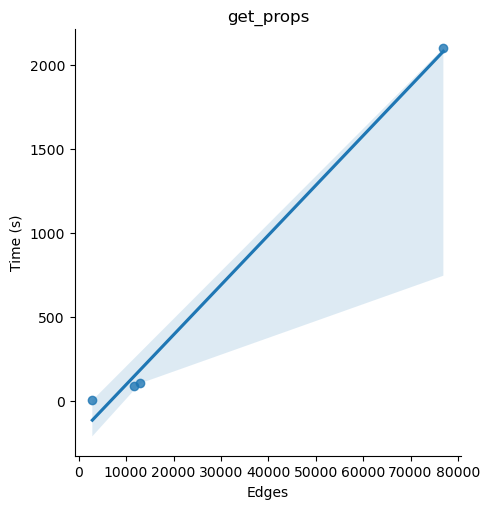

In [9]:
for prop, times in raw_times.items():
    if prop != 'edges' and prop != 'nodes':
        ax = sns.lmplot(
            data = raw_df,
            x = 'edges',
            y = prop, 
        )
        ax.set(
            xlabel='Edges',
            ylabel='Time (s)',
            title= prop
        )
        plt.show()